<a href="https://colab.research.google.com/github/MorganWilliams9/model-portfolio-dfm/blob/main/DFM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  ok   UK Equity      VUKE.L    2140 rows
  ok   Global Equity  SWDA.L    2140 rows
  ok   EM Equity      VFEM.L    2139 rows
  ok   Global Bonds   AGGG.L    2141 rows
  ok   UK Gilts       IGLT.L    2140 rows
  ok   Gold           SGLN.L    2141 rows
Common backtest window: 2018-01-02 to 2026-06-24  (2140 trading days)

First few daily returns:
            UK Equity  Global Equity  EM Equity  Global Bonds  UK Gilts  \
Date                                                                      
2018-01-03   0.001917       0.011424   0.016418      0.000545  0.006563   
2018-01-04   0.002649       0.006542   0.006270      0.000495 -0.000569   
2018-01-05   0.002055       0.002330   0.003802     -0.001733 -0.000948   
2018-01-08  -0.001904       0.001591   0.000210      0.000000  0.000380   
2018-01-09   0.004697       0.007574   0.003155     -0.002729 -0.003416   

                Gold  
Date                  
2018-01-03  0.007365  
2018-01-04  0.000000  
2018-01-05 -0.000783  
2018-01-08 

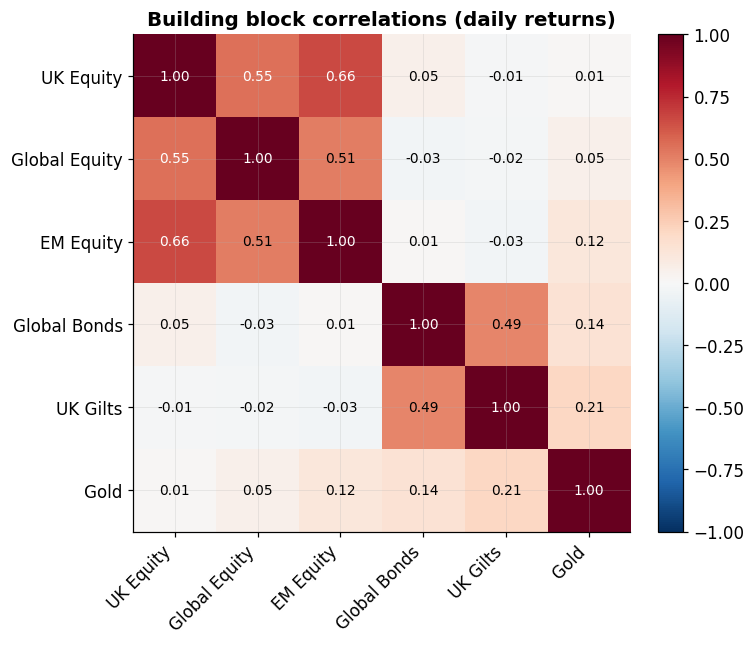

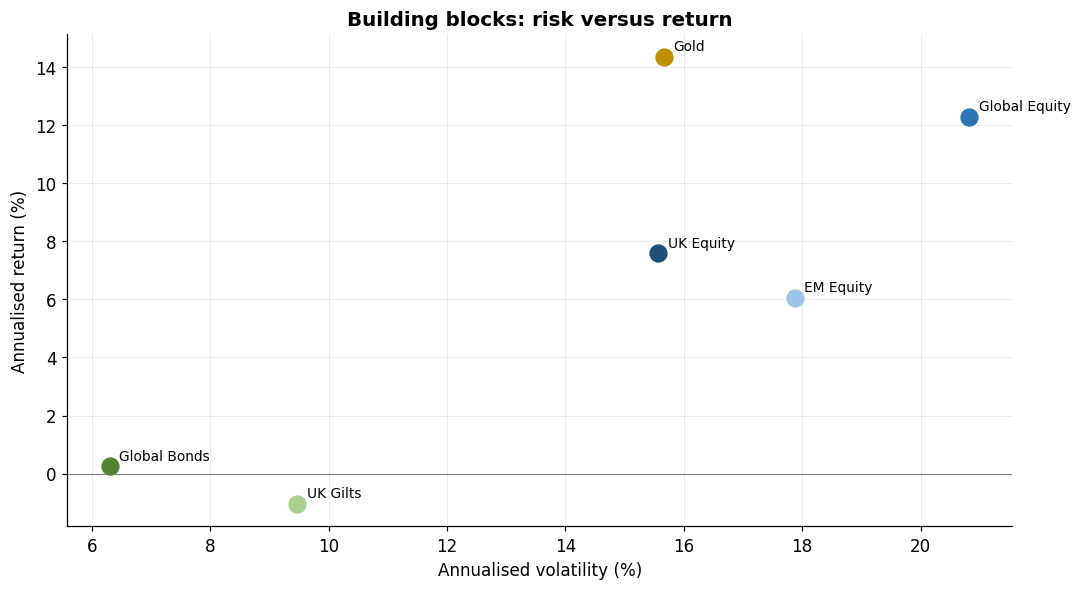

Model portfolio daily returns built: ['Cautious', 'Balanced', 'Adventurous']


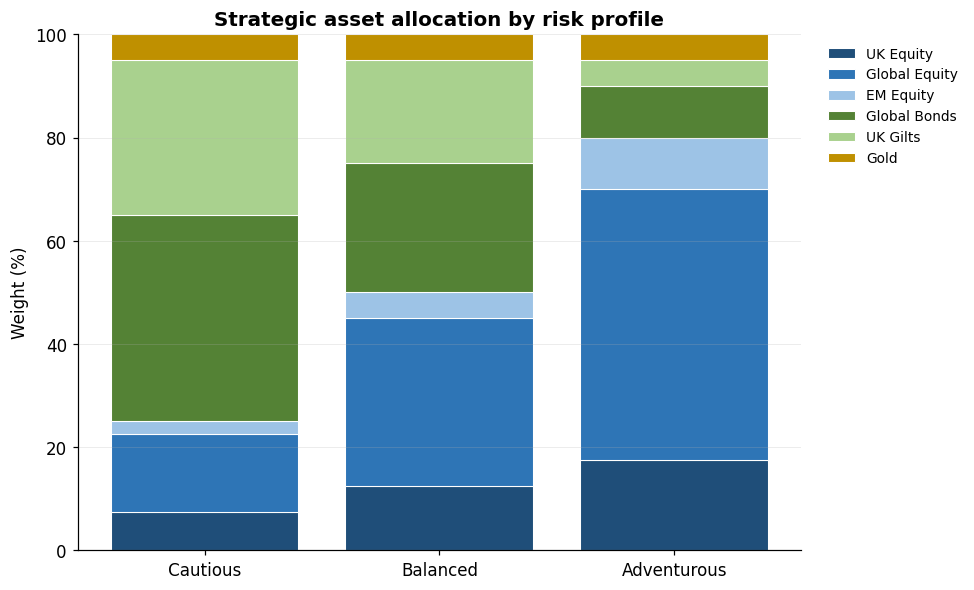

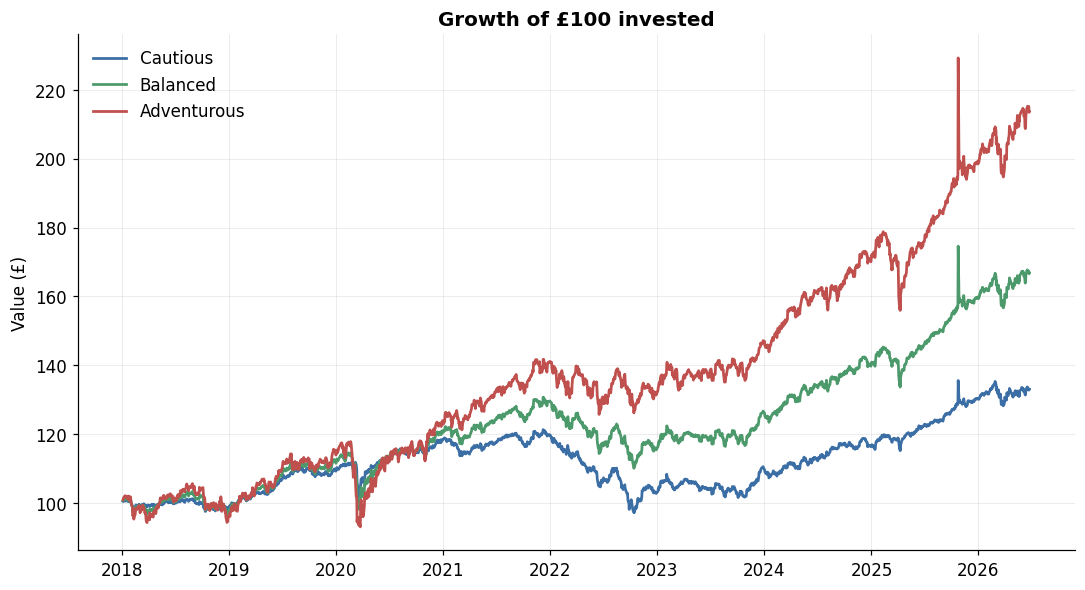

Model portfolio performance:
             CAGR Volatility  Sharpe  Sortino Max Drawdown  Calmar Best Year  \
Cautious     3.4%       6.4%    0.54     0.73       -19.9%    0.17     11.6%   
Balanced     6.2%       9.2%    0.67     0.84       -15.8%    0.39     14.2%   
Adventurous  9.4%      13.8%    0.68     0.82       -21.0%    0.44     18.4%   

            Worst Year % Positive Months  
Cautious        -13.9%             60.8%  
Balanced        -10.5%             63.7%  
Adventurous      -6.4%             63.7%  


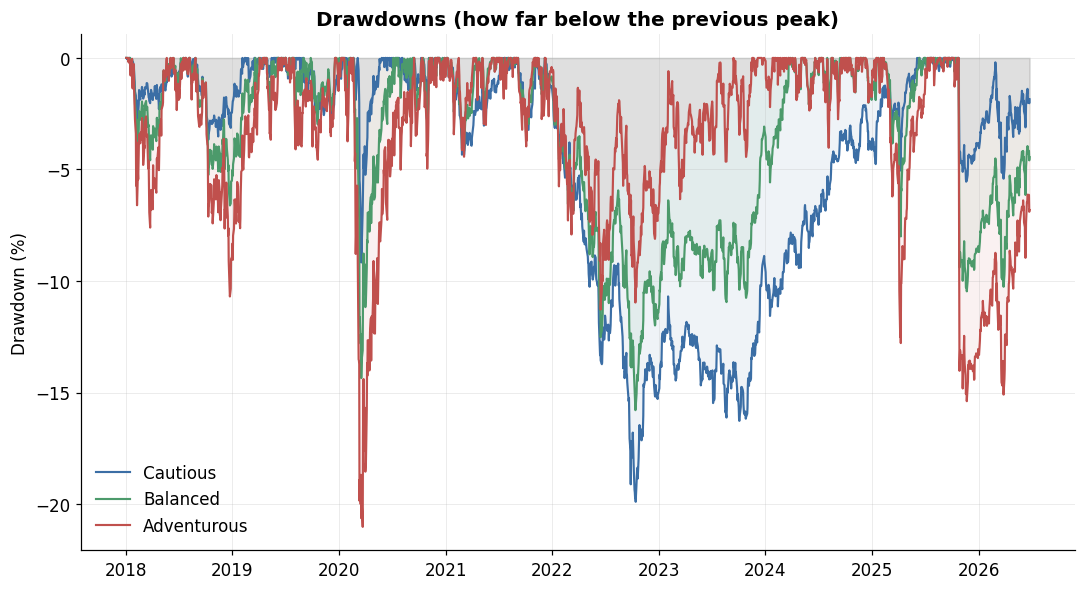

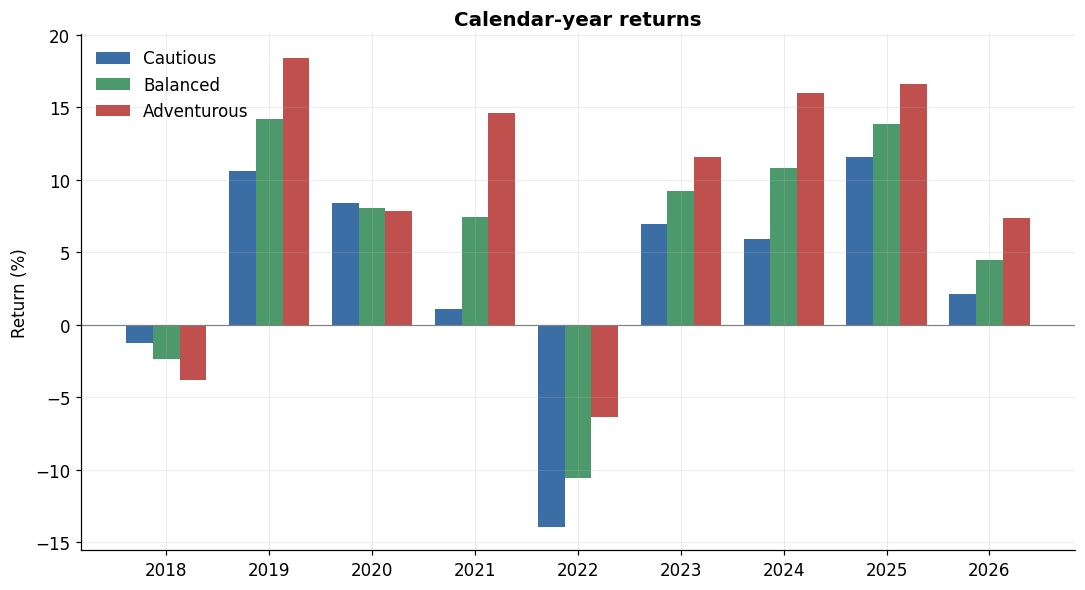

Balanced vs 60/40 benchmark, full period:
  allocation     -6.03%
  selection     -17.89%
  interaction     2.49%
  total_active  -21.43%


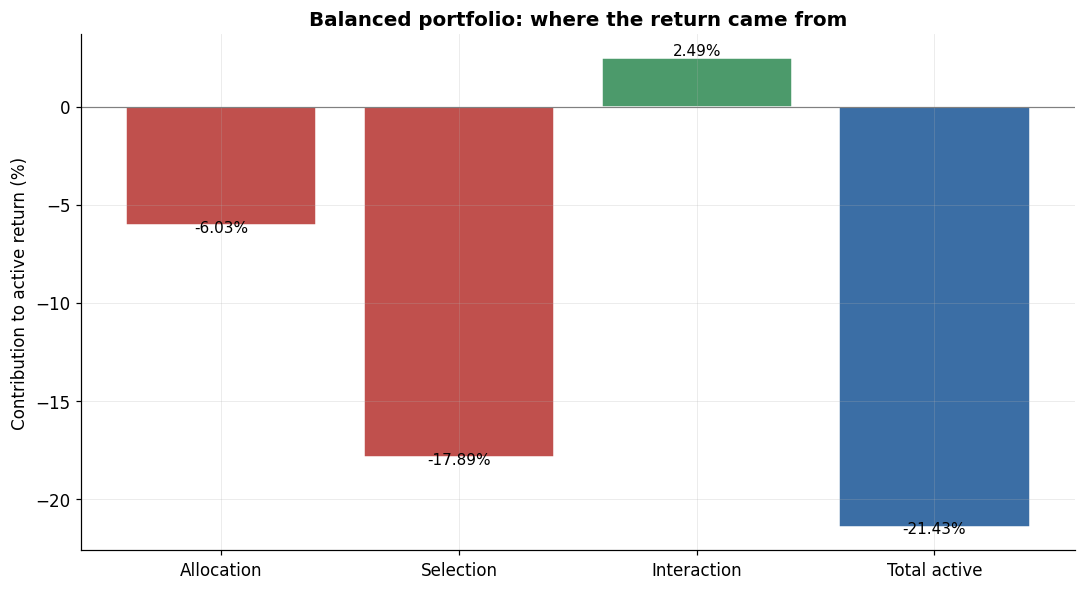

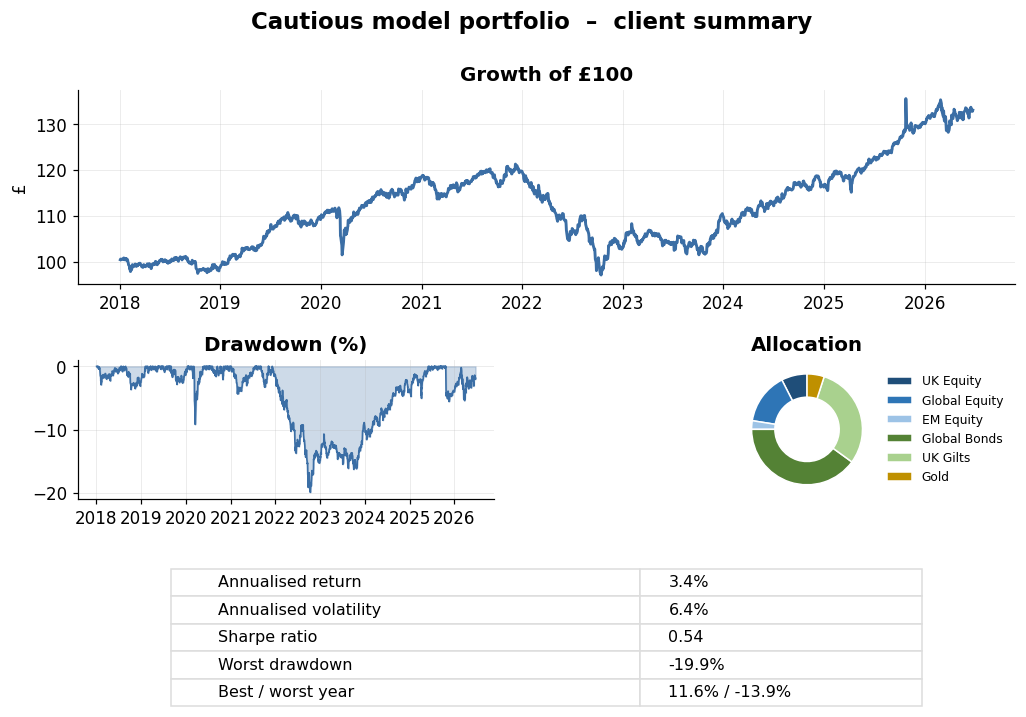

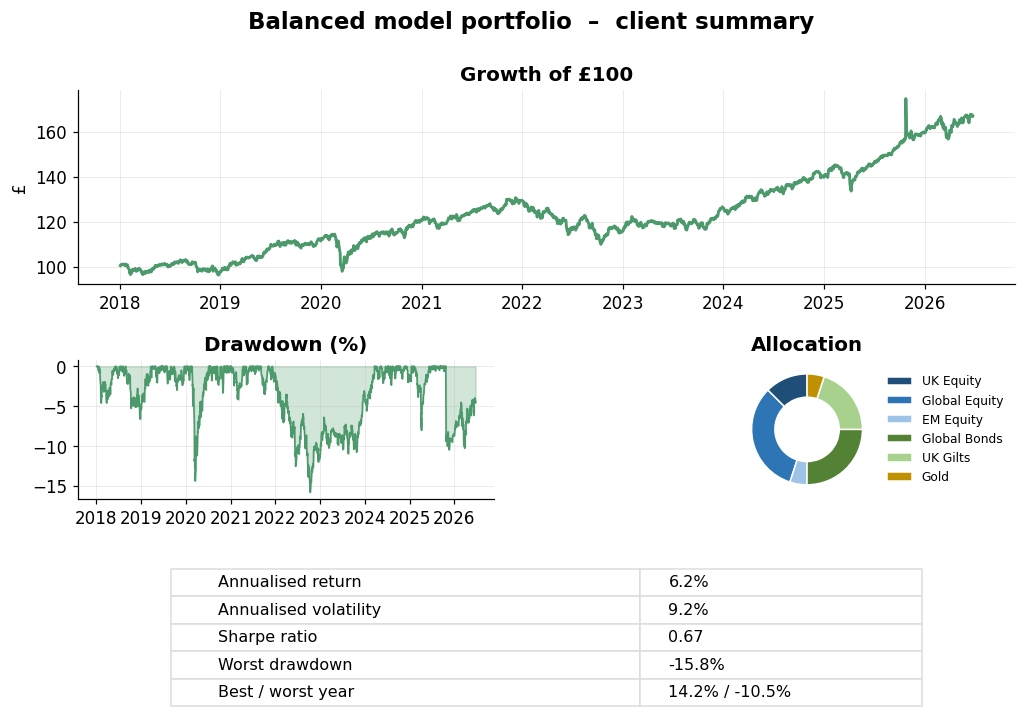

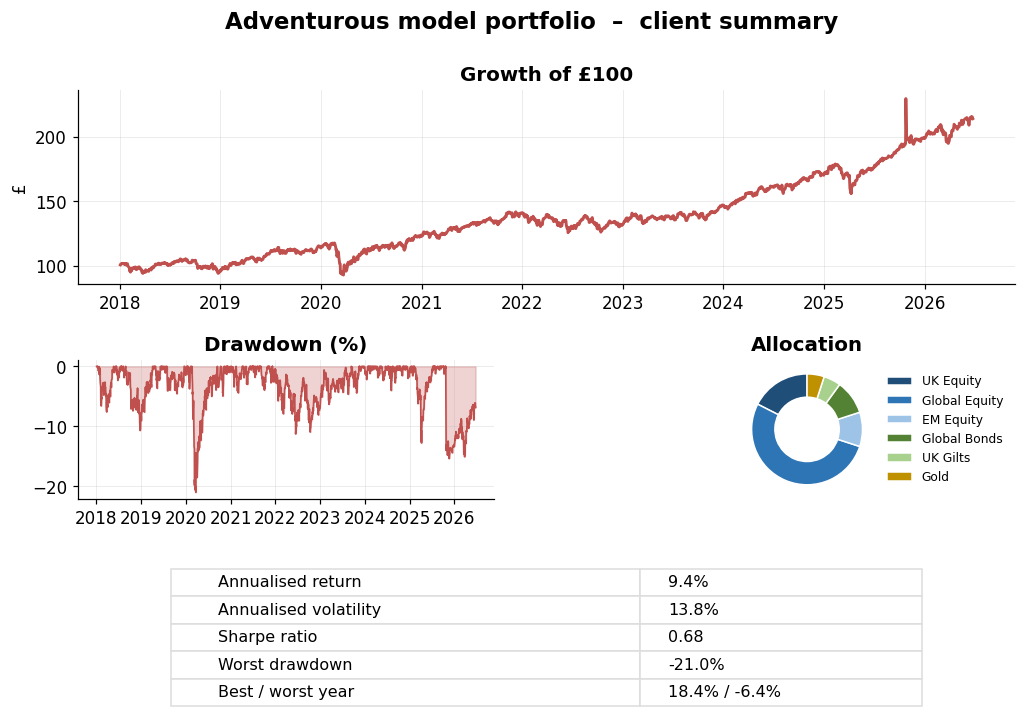

In [1]:
# %% [markdown]
# # Model Portfolio Construction and Management
# ### A discretionary fund management (DFM) workflow in Python
#
# This notebook builds three risk-graded model portfolios (Cautious, Balanced,
# Adventurous) from low-cost ETF building blocks, backtests them through real
# market stress, breaks the returns down into allocation versus selection
# decisions, and produces a client-ready report.
#
# The point of the project is to show the *decisions* a discretionary manager
# makes, not to write clever code. Read the comments for the reasoning.
#
# **Run order:** top to bottom. Run the install cell once, then Runtime > Run all.

# %% [markdown]
# ## 0. Setup, imports and configuration
# Everything you would want to change lives here: the building blocks, the model
# weights, the date range, and the colour palette. Change these and the whole
# notebook updates.

# %%
# Install dependencies. yfinance is the only one not pre-installed on Colab.
# The "-q" keeps the output quiet. Run this cell once per session.
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)

# %%
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

try:
    import yfinance as yf
except Exception as e:
    yf = None
    print("yfinance not available yet, re-run the install cell.", e)

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# Building blocks. Each asset class maps to one London-listed ETF.
# These are the "Lego bricks" a DFM allocates across. Swap any ticker here and
# the rest of the notebook follows. (.L = London Stock Exchange.)
BUILDING_BLOCKS = {
    "UK Equity":     "VUKE.L",   # Vanguard FTSE 100
    "Global Equity": "SWDA.L",   # iShares Core MSCI World (developed markets)
    "EM Equity":     "VFEM.L",   # Vanguard FTSE Emerging Markets
    "Global Bonds":  "AGGG.L",   # iShares Core Global Aggregate Bond
    "UK Gilts":      "IGLT.L",   # iShares Core UK Gilts
    "Gold":          "SGLN.L",   # iShares Physical Gold
}

# The three model portfolios. Weights are in PERCENT and must sum to 100.
# These are the central deliverable: the manager's strategic asset allocation
# for each client risk profile. The logic: as risk tolerance rises, equity goes
# up and bonds come down. Gold stays as a small diversifier throughout.
MODEL_PORTFOLIOS = {
    "Cautious":    {"UK Equity": 7.5,  "Global Equity": 15.0, "EM Equity": 2.5,
                    "Global Bonds": 40.0, "UK Gilts": 30.0, "Gold": 5.0},
    "Balanced":    {"UK Equity": 12.5, "Global Equity": 32.5, "EM Equity": 5.0,
                    "Global Bonds": 25.0, "UK Gilts": 20.0, "Gold": 5.0},
    "Adventurous": {"UK Equity": 17.5, "Global Equity": 52.5, "EM Equity": 10.0,
                    "Global Bonds": 10.0, "UK Gilts": 5.0,  "Gold": 5.0},
}

START_DATE   = "2018-01-01"   # backtest start (limited by the youngest ETF)
END_DATE     = None           # None = up to today
REBAL_FREQ   = "YE"           # rebalance yearly (year-end). "QE" for quarterly.
REBAL_COST_BPS = 0.0          # round-trip rebalancing cost in basis points (0 = off)
RISK_FREE    = 0.0            # annual risk-free rate used in Sharpe/Sortino
TRADING_DAYS = 252

# Consistent colours so every chart speaks the same language.
PALETTE = {
    "Cautious": "#3B6EA5", "Balanced": "#4C9A6B", "Adventurous": "#C0504D",
    "Benchmark": "#8C8C8C", "60/40 Benchmark": "#8C8C8C",
}
ASSET_COLOURS = {
    "UK Equity": "#1F4E79", "Global Equity": "#2E75B6", "EM Equity": "#9DC3E6",
    "Global Bonds": "#548235", "UK Gilts": "#A9D18E", "Gold": "#BF9000",
}

# Clean, readable chart style applied notebook-wide.
plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.frameon": False,
})

# %% [markdown]
# ## PURE FUNCTIONS
# All the reusable analytics live here as small, tested functions. Nothing below
# touches the internet, so each piece can be checked on its own.

# %%
# ===== PURE FUNCTIONS START =====

def _extract_close(data, ticker):
    """Pull a single adjusted-close price Series out of a yfinance result.

    yfinance changes its column shape depending on version and number of
    tickers, so we handle both the flat and the MultiIndex case rather than
    assuming one layout and crashing later.
    """
    if data is None or len(data) == 0:
        raise ValueError("empty download")
    if isinstance(data.columns, pd.MultiIndex):
        # Columns look like ('Close', 'VUKE.L'); grab the Close block.
        close = data["Close"]
        if isinstance(close, pd.DataFrame):
            close = close[ticker] if ticker in close.columns else close.iloc[:, 0]
    else:
        close = data["Close"]
    return close.astype(float)


def clean_prices(raw, ffill_limit=5):
    """Align price series onto a common, gap-free daily calendar.

    Steps, and why each one matters:
      1. Sort by date and drop any duplicate dates.
      2. Forward-fill only SMALL gaps (different exchange holidays), never long
         ones, because filling a long gap invents prices that never traded.
      3. Drop the lead-in period before every asset has started trading, so the
         backtest only runs over a window where all building blocks exist.
    Returns the cleaned price DataFrame.
    """
    prices = raw.sort_index()
    prices = prices[~prices.index.duplicated(keep="last")]
    prices = prices.ffill(limit=ffill_limit)
    prices = prices.dropna(how="any")        # common window only
    if prices.empty:
        raise ValueError("no overlapping dates across all building blocks")
    return prices


def to_returns(prices):
    """Daily simple returns. Returns are scale-free, so currency/pence quirks in
    the raw price level wash out here."""
    return prices.pct_change().dropna(how="any")


def annual_return(rets):
    """Compound annual growth rate (CAGR) from a daily return series."""
    n_years = len(rets) / TRADING_DAYS
    if n_years <= 0:
        return np.nan
    total_growth = (1.0 + rets).prod()
    return total_growth ** (1.0 / n_years) - 1.0


def annual_vol(rets):
    """Annualised volatility (standard deviation scaled by root-time)."""
    return rets.std() * np.sqrt(TRADING_DAYS)


def sharpe_ratio(rets, rf=RISK_FREE):
    """Excess return per unit of total risk. Higher is better."""
    vol = annual_vol(rets)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return (annual_return(rets) - rf) / vol


def drawdown_series(rets):
    """Running drop from the previous peak. The classic 'underwater' curve."""
    cum = (1.0 + rets).cumprod()
    peak = cum.cummax()
    return cum / peak - 1.0


def max_drawdown(rets):
    """The worst peak-to-trough fall over the period. Always <= 0."""
    return drawdown_series(rets).min()


def sortino_ratio(rets, rf=RISK_FREE):
    """Like Sharpe but only penalises downside volatility, which is closer to
    how a client actually experiences risk."""
    downside = rets[rets < 0].std() * np.sqrt(TRADING_DAYS)
    if downside == 0 or np.isnan(downside):
        return np.nan
    return (annual_return(rets) - rf) / downside


def calmar_ratio(rets):
    """Return earned per unit of worst-case loss (CAGR / |max drawdown|)."""
    mdd = max_drawdown(rets)
    if mdd == 0 or np.isnan(mdd):
        return np.nan
    return annual_return(rets) / abs(mdd)


def calendar_year_returns(rets):
    """Total return for each calendar year. Works on a Series or a DataFrame."""
    return (1.0 + rets).resample("YE").prod() - 1.0


def performance_summary(rets, rf=RISK_FREE):
    """Bundle the headline metrics for one return series into a tidy dict."""
    return {
        "CAGR":          annual_return(rets),
        "Volatility":    annual_vol(rets),
        "Sharpe":        sharpe_ratio(rets, rf),
        "Sortino":       sortino_ratio(rets, rf),
        "Max Drawdown":  max_drawdown(rets),
        "Calmar":        calmar_ratio(rets),
        "Best Year":     calendar_year_returns(rets).max(),
        "Worst Year":    calendar_year_returns(rets).min(),
        "% Positive Months": (
            ((1 + rets).resample("ME").prod() - 1) > 0
        ).mean(),
    }


def backtest_portfolio(returns_df, weights, rebalance_freq=REBAL_FREQ,
                       cost_bps=REBAL_COST_BPS):
    """Backtest a fixed-weight portfolio WITH realistic weight drift.

    The subtle part most people get wrong: between rebalances the weights drift
    as each asset moves, so the portfolio return uses yesterday's DRIFTED
    weights, not the static target. On each rebalance date we reset to target
    and optionally charge a turnover cost.

    A simple day-by-day loop is used on purpose. Over a handful of assets and a
    few thousand days it is instant, and it is far easier to explain in an
    interview than a vectorised one-liner. For a large universe you would
    vectorise this.

    Parameters
    ----------
    returns_df : DataFrame of daily simple returns (columns = asset classes)
    weights    : dict of {asset class: percent weight}
    Returns a daily return Series for the portfolio.
    """
    assets = list(weights.keys())
    missing = [a for a in assets if a not in returns_df.columns]
    if missing:
        raise KeyError(f"weights reference assets not in the data: {missing}")

    w_target = np.array([weights[a] for a in assets], dtype=float)
    w_target = w_target / w_target.sum()          # normalise to fractions
    R = returns_df[assets].to_numpy()
    idx = returns_df.index
    rebal_dates = set(returns_df.resample(rebalance_freq).last().index)
    cost = cost_bps / 1e4

    port = np.empty(len(idx))
    w = w_target.copy()
    for t in range(len(idx)):
        r = R[t]
        port[t] = float(np.dot(w, r))             # today's portfolio return
        w = w * (1.0 + r)                          # let weights drift
        total = w.sum()
        if total > 0:
            w = w / total
        if idx[t] in rebal_dates:                  # rebalance back to target
            turnover = np.abs(w_target - w).sum()
            port[t] -= turnover * cost
            w = w_target.copy()
    return pd.Series(port, index=idx, name="portfolio")


def compound_return(rets):
    """Total compounded return over the whole period (a single number)."""
    return (1.0 + rets).prod() - 1.0


def blended_bucket_return(returns_df, sleeve_weights):
    """Compound return of a sub-portfolio of sleeves at given internal weights.

    Used by the attribution step to get the return of, say, the whole 'Equity'
    bucket given how the model splits it across UK / Global / EM.
    """
    assets = list(sleeve_weights.keys())
    w = np.array([sleeve_weights[a] for a in assets], dtype=float)
    w = w / w.sum()
    daily = returns_df[assets].to_numpy() @ w
    return float(np.prod(1.0 + daily) - 1.0)


def brinson_attribution(wP, wB, rP, rB):
    """Brinson-Hood-Beebower performance attribution.

    Splits a portfolio's excess return over a benchmark into three parts:
      allocation  : did we over/under-weight the right buckets?
      selection   : within each bucket, did our holdings beat the bucket index?
      interaction : the cross term between the two.
    By construction allocation + selection + interaction == rP_total - rB_total.

    All inputs are dicts keyed by the same buckets. Weights are fractions,
    returns are period totals.
    """
    buckets = list(wB.keys())
    rB_total = sum(wB[b] * rB[b] for b in buckets)
    allocation = sum((wP[b] - wB[b]) * (rB[b] - rB_total) for b in buckets)
    selection  = sum(wB[b] * (rP[b] - rB[b]) for b in buckets)
    interaction = sum((wP[b] - wB[b]) * (rP[b] - rB[b]) for b in buckets)
    return {"allocation": allocation, "selection": selection,
            "interaction": interaction, "total_active": allocation + selection + interaction}

# ===== PURE FUNCTIONS END =====

# %% [markdown]
# ## 1. Data collection
# Download adjusted-close prices for every building block. The download is
# wrapped so that one bad ticker warns and is skipped instead of killing the
# whole run, and each ticker gets a few retries because Yahoo is flaky.

# %%
def download_prices(blocks, start=START_DATE, end=END_DATE, retries=3):
    """Download adjusted close prices for a dict of {name: ticker}.

    Returns a DataFrame keyed by the friendly asset-class name. Any ticker that
    fails after all retries is reported and dropped, so a single outage does not
    sink the project.
    """
    if yf is None:
        raise RuntimeError("yfinance is not imported, run the install cell first")

    series, failed = {}, []
    for name, ticker in blocks.items():
        for attempt in range(1, retries + 1):
            try:
                raw = yf.download(ticker, start=start, end=end,
                                  auto_adjust=True, progress=False)
                series[name] = _extract_close(raw, ticker)
                print(f"  ok   {name:<14} {ticker:<8} {len(series[name]):>5} rows")
                break
            except Exception as exc:
                if attempt == retries:
                    failed.append((name, ticker, str(exc)))
                    print(f"  FAIL {name:<14} {ticker:<8} {exc}")

    if not series:
        raise RuntimeError("no price data downloaded at all, check connection/tickers")
    if failed:
        print(f"\nDropped {len(failed)} ticker(s): {[f[0] for f in failed]}")
    return pd.DataFrame(series)


print("Downloading building blocks...")
raw_prices = download_prices(BUILDING_BLOCKS)

# %% [markdown]
# ## 2. Data cleaning and feature engineering
# Align the series onto a common calendar, then turn prices into the daily
# returns that every later calculation runs on.

# %%
prices = clean_prices(raw_prices)
returns = to_returns(prices)

print(f"Common backtest window: {prices.index.min().date()} "
      f"to {prices.index.max().date()}  ({len(returns)} trading days)")
print("\nFirst few daily returns:")
display(returns.head()) if "display" in dir() else print(returns.head())

# %% [markdown]
# ## 3. Building block analysis
# Before building anything, understand the bricks: how each asset class behaves
# on its own, and crucially how they move together. Low correlations are what
# make diversification work.

# %%
# Per-asset summary table.
block_stats = pd.DataFrame({name: performance_summary(returns[name])
                            for name in returns.columns}).T
block_stats_fmt = block_stats.copy()
for col in ["CAGR", "Volatility", "Max Drawdown", "Best Year", "Worst Year", "% Positive Months"]:
    block_stats_fmt[col] = (block_stats_fmt[col] * 100).round(1).astype(str) + "%"
for col in ["Sharpe", "Sortino", "Calmar"]:
    block_stats_fmt[col] = block_stats_fmt[col].round(2)
print("Building block statistics:")
display(block_stats_fmt) if "display" in dir() else print(block_stats_fmt)

# %%
# Correlation heatmap. The story to read off it: bonds and gold sit apart from
# equities, which is exactly why they earn a place in the portfolios.
corr = returns.corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black", fontsize=9)
ax.set_title("Building block correlations (daily returns)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# %%
# Risk vs return scatter. Each brick plotted by what you pay (volatility) and
# what you got (return). The portfolios will sit inside this cloud.
fig, ax = plt.subplots()
for name in returns.columns:
    ax.scatter(annual_vol(returns[name]) * 100, annual_return(returns[name]) * 100,
               s=120, color=ASSET_COLOURS.get(name, "#444"), zorder=3)
    ax.annotate(name, (annual_vol(returns[name]) * 100, annual_return(returns[name]) * 100),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("Annualised return (%)")
ax.set_title("Building blocks: risk versus return")
ax.axhline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.show()

# %% [markdown]
# ## 4. Build the model portfolios
# Apply the strategic weights, with yearly rebalancing, to produce a daily
# return stream for each risk profile. Then show the allocations and the growth
# of a notional 100 pounds.

# %%
portfolio_returns = pd.DataFrame({
    name: backtest_portfolio(returns, weights)
    for name, weights in MODEL_PORTFOLIOS.items()
})
print("Model portfolio daily returns built:", list(portfolio_returns.columns))

# %%
# Allocation chart: one stacked bar per risk profile.
fig, ax = plt.subplots(figsize=(9, 5.5))
profiles = list(MODEL_PORTFOLIOS.keys())
bottom = np.zeros(len(profiles))
for asset in BUILDING_BLOCKS:
    vals = np.array([MODEL_PORTFOLIOS[p].get(asset, 0) for p in profiles], dtype=float)
    ax.bar(profiles, vals, bottom=bottom, label=asset,
           color=ASSET_COLOURS.get(asset, "#999"), edgecolor="white", linewidth=0.7)
    bottom += vals
ax.set_ylabel("Weight (%)"); ax.set_ylim(0, 100)
ax.set_title("Strategic asset allocation by risk profile")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

# %%
# Growth of 100 pounds for each profile.
growth = 100 * (1 + portfolio_returns).cumprod()
fig, ax = plt.subplots()
for name in growth.columns:
    ax.plot(growth.index, growth[name], label=name, color=PALETTE[name], lw=1.8)
ax.set_title("Growth of \u00a3100 invested")
ax.set_ylabel("Value (\u00a3)")
ax.legend()
plt.tight_layout(); plt.show()

# %% [markdown]
# ## 5. Backtest and stress test
# Headline metrics side by side, the underwater drawdown chart (the honest view
# a client cares about), and calendar-year returns including the 2022 sell-off
# when both equities and bonds fell together.

# %%
summary = pd.DataFrame({name: performance_summary(portfolio_returns[name])
                        for name in portfolio_returns.columns}).T
summary_fmt = summary.copy()
for col in ["CAGR", "Volatility", "Max Drawdown", "Best Year", "Worst Year", "% Positive Months"]:
    summary_fmt[col] = (summary_fmt[col] * 100).round(1).astype(str) + "%"
for col in ["Sharpe", "Sortino", "Calmar"]:
    summary_fmt[col] = summary_fmt[col].round(2)
print("Model portfolio performance:")
display(summary_fmt) if "display" in dir() else print(summary_fmt)

# %%
# Underwater drawdown chart.
fig, ax = plt.subplots()
for name in portfolio_returns.columns:
    dd = drawdown_series(portfolio_returns[name]) * 100
    ax.plot(dd.index, dd, label=name, color=PALETTE[name], lw=1.4)
    ax.fill_between(dd.index, dd, 0, color=PALETTE[name], alpha=0.08)
ax.set_title("Drawdowns (how far below the previous peak)")
ax.set_ylabel("Drawdown (%)"); ax.legend()
plt.tight_layout(); plt.show()

# %%
# Calendar-year returns, grouped bars.
cal = calendar_year_returns(portfolio_returns) * 100
cal.index = cal.index.year
fig, ax = plt.subplots()
x = np.arange(len(cal)); width = 0.26
for i, name in enumerate(cal.columns):
    ax.bar(x + (i - 1) * width, cal[name], width, label=name, color=PALETTE[name])
ax.set_xticks(x); ax.set_xticklabels(cal.index)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Return (%)"); ax.set_title("Calendar-year returns")
ax.legend()
plt.tight_layout(); plt.show()

# %% [markdown]
# ## 6. Performance attribution (Brinson)
# Take the Balanced portfolio and ask the question every client and every boss
# asks: where did the return actually come from? We compare against a plain
# 60/40 benchmark and split the difference into the allocation decision (our
# asset-class tilts) and the selection decision (our specific mix within each
# bucket). Because we hold index trackers, selection is small by design, which
# is itself the honest, correct answer.

# %%
# Map the six sleeves into three macro buckets.
BUCKETS = {
    "Equity":       ["UK Equity", "Global Equity", "EM Equity"],
    "Bonds":        ["Global Bonds", "UK Gilts"],
    "Alternatives": ["Gold"],
}
# Benchmark: classic 60/40, no alternatives. Bucket returns use a single
# representative index each.
BENCH_WEIGHTS = {"Equity": 0.60, "Bonds": 0.40, "Alternatives": 0.00}
BENCH_PROXY   = {"Equity": "Global Equity", "Bonds": "Global Bonds", "Alternatives": "Gold"}

profile = "Balanced"
w = MODEL_PORTFOLIOS[profile]

# Portfolio bucket weights (fractions) and portfolio bucket returns.
wP, rP, rB = {}, {}, {}
for bucket, sleeves in BUCKETS.items():
    wP[bucket] = sum(w[s] for s in sleeves) / 100.0
    sleeve_w = {s: w[s] for s in sleeves}
    rP[bucket] = blended_bucket_return(returns, sleeve_w)      # our mix
    rB[bucket] = compound_return(returns[BENCH_PROXY[bucket]])  # benchmark index

attrib = brinson_attribution(wP, BENCH_WEIGHTS, rP, rB)
print(f"{profile} vs 60/40 benchmark, full period:")
for k, v in attrib.items():
    print(f"  {k:<13} {v*100:6.2f}%")

# %%
# Attribution waterfall.
labels = ["Allocation", "Selection", "Interaction", "Total active"]
vals = [attrib["allocation"]*100, attrib["selection"]*100,
        attrib["interaction"]*100, attrib["total_active"]*100]
colours = ["#4C9A6B" if v >= 0 else "#C0504D" for v in vals[:-1]] + ["#3B6EA5"]
fig, ax = plt.subplots()
ax.bar(labels, vals, color=colours, edgecolor="white")
for i, v in enumerate(vals):
    ax.text(i, v + (0.15 if v >= 0 else -0.35), f"{v:.2f}%", ha="center", fontsize=10)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Contribution to active return (%)")
ax.set_title(f"{profile} portfolio: where the return came from")
plt.tight_layout(); plt.show()

# %% [markdown]
# ## 7. Client report
# A single tearsheet per profile that an adviser could put in front of a client:
# the growth line, the drawdown, the allocation, and the numbers that matter, on
# one page.

# %%
def build_tearsheet(profile):
    """Render a one-page summary figure for a single risk profile."""
    r = portfolio_returns[profile]
    g = 100 * (1 + r).cumprod()
    dd = drawdown_series(r) * 100
    stats = performance_summary(r)
    col = PALETTE[profile]

    fig = plt.figure(figsize=(11, 7.2))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.4, 1.0, 0.9], hspace=0.5, wspace=0.25)
    fig.suptitle(f"{profile} model portfolio  \u2013  client summary",
                 fontsize=15, fontweight="bold", y=0.98)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(g.index, g, color=col, lw=1.9); ax1.set_title("Growth of \u00a3100")
    ax1.set_ylabel("\u00a3")

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.fill_between(dd.index, dd, 0, color=col, alpha=0.25)
    ax2.plot(dd.index, dd, color=col, lw=1.1); ax2.set_title("Drawdown (%)")

    ax3 = fig.add_subplot(gs[1, 1])
    sleeves = list(MODEL_PORTFOLIOS[profile].keys())
    vals = [MODEL_PORTFOLIOS[profile][s] for s in sleeves]
    ax3.pie(vals, colors=[ASSET_COLOURS.get(s, "#999") for s in sleeves],
            startangle=90, wedgeprops=dict(width=0.42, edgecolor="white"))
    ax3.set_title("Allocation")
    ax3.legend(sleeves, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)

    ax4 = fig.add_subplot(gs[2, :]); ax4.axis("off")
    rows = [
        ("Annualised return", f"{stats['CAGR']*100:.1f}%"),
        ("Annualised volatility", f"{stats['Volatility']*100:.1f}%"),
        ("Sharpe ratio", f"{stats['Sharpe']:.2f}"),
        ("Worst drawdown", f"{stats['Max Drawdown']*100:.1f}%"),
        ("Best / worst year", f"{stats['Best Year']*100:.1f}% / {stats['Worst Year']*100:.1f}%"),
    ]
    tbl = ax4.table(cellText=[[k, v] for k, v in rows],
                    colWidths=[0.5, 0.3], cellLoc="left", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1, 1.5)
    for (row, _), cell in tbl.get_celld().items():
        cell.set_edgecolor("#dddddd")
    plt.show()
    return fig

for p in MODEL_PORTFOLIOS:
    build_tearsheet(p)

# %% [markdown]
# ## 8. Notes, assumptions and honest limitations
# - The backtest window is set by the youngest ETF, so it is a few years rather
#   than a few decades. It still spans the 2022 stock-and-bond sell-off and the
#   2020 COVID shock, which are the stresses that matter.
# - Holdings are index trackers, so the selection effect in attribution is small
#   on purpose. A manager using active funds would see a larger selection term.
# - Returns ignore platform and fund fees and assume costless yearly rebalancing
#   unless REBAL_COST_BPS is switched on. Tax is not modelled.
# - Currency is not hedged across every sleeve, so some FX is baked into returns.
#
# These are deliberate simplifications, not oversights. Each one is a clean place
# to extend the project. See the README for the upgrade path.

